<a href="https://colab.research.google.com/github/ommalewar8154-wq/DAA-Project/blob/main/tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Records
   CGPA  Aptitude  Communication  Internship  Placement
0   8.5        80             75           1          1
1   7.2        65             60           0          0
2   9.1        90             85           1          1
3   6.8        55             50           0          0
4   8.0        78             72           1          1

Accuracy: 100.0 %

Confusion Matrix
[[2 0]
 [0 2]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



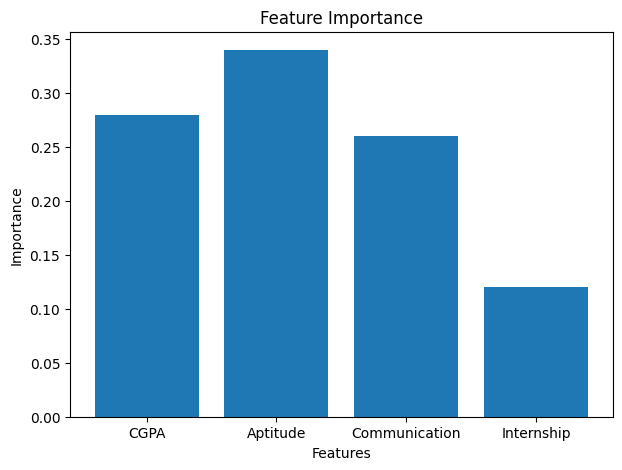


Prediction: Student is Likely to be Placed


In [ ]:
# Intelligent Placement Prediction System (Google Colab Runnable)

# Install libraries (only if needed)
# !pip install pandas scikit-learn matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os

# ----------------------------
# Create Dataset Automatically
# ----------------------------
if not os.path.exists("placement_data.csv"):

    data = {
        "CGPA":[8.5,7.2,9.1,6.8,8.0,7.5,8.9,6.5,9.3,7.8,
                8.2,7.1,8.7,6.9,9.0,7.6,8.4,7.3,8.8,6.7],
        "Aptitude":[80,65,90,55,78,70,88,60,95,75,
                    82,68,86,58,92,72,79,69,89,57],
        "Communication":[75,60,85,50,72,68,90,55,92,70,
                         78,63,84,54,91,71,77,65,88,53],
        "Internship":[1,0,1,0,1,0,1,0,1,1,
                      1,0,1,0,1,1,1,0,1,0],
        "Placement":[1,0,1,0,1,1,1,0,1,1,
                     1,0,1,0,1,1,1,0,1,0]
    }

    df = pd.DataFrame(data)
    df.to_csv("placement_data.csv", index=False)

# ----------------------------
# Load Dataset
# ----------------------------
df = pd.read_csv("placement_data.csv")

print("First 5 Records")
print(df.head())

# ----------------------------
# Features & Target
# ----------------------------
X = df.drop("Placement", axis=1)
y = df["Placement"]

# ----------------------------
# Train/Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# Train Model
# ----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ----------------------------
# Prediction
# ----------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred)*100,2),"%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report")
print(classification_report(y_test,y_pred))

# ----------------------------
# Feature Importance
# ----------------------------
importance=model.feature_importances_

plt.figure(figsize=(7,5))
plt.bar(X.columns,importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# ----------------------------
# Predict New Student
# ----------------------------
new_student=pd.DataFrame({
    "CGPA":[8.5],
    "Aptitude":[80],
    "Communication":[75],
    "Internship":[1]
})

prediction=model.predict(new_student)

if prediction[0]==1:
    print("\nPrediction: Student is Likely to be Placed")
else:
    print("\nPrediction: Student is Not Likely to be Placed")

First 10 Transactions
   Transaction_ID       Amount
0               1  5496.714153
1               2  4861.735699
2               3  5647.688538
3               4  6523.029856
4               5  4765.846625
5               6  4765.863043
6               7  6579.212816
7               8  5767.434729
8               9  4530.525614
9              10  5542.560044

Detection Results
    Transaction_ID       Amount Prediction
0                1  5496.714153     Normal
1                2  4861.735699     Normal
2                3  5647.688538     Normal
3                4  6523.029856     Normal
4                5  4765.846625     Normal
5                6  4765.863043     Normal
6                7  6579.212816     Normal
7                8  5767.434729     Normal
8                9  4530.525614     Normal
9               10  5542.560044     Normal
10              11  4536.582307     Normal
11              12  4534.270246     Normal
12              13  5241.962272     Normal
13              

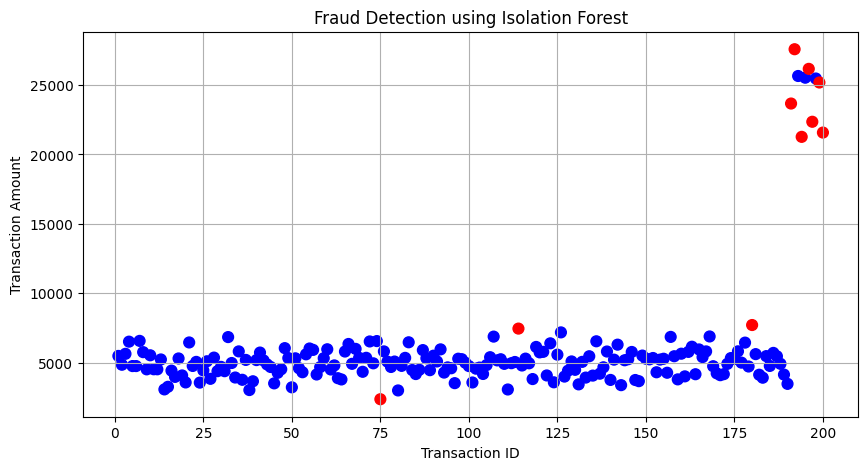


Prediction: Fraudulent Transaction


In [ ]:
# Fraud Detection System using Anomaly Detection (Google Colab)

# Install libraries (if required)
# !pip install pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import os

# ---------------------------------
# Step 1: Create Sample Dataset
# ---------------------------------
if not os.path.exists("transactions.csv"):

    np.random.seed(42)

    normal_amounts = np.random.normal(5000, 1000, 190)
    fraud_amounts = np.random.normal(25000, 3000, 10)

    amounts = np.concatenate([normal_amounts, fraud_amounts])

    df = pd.DataFrame({
        "Transaction_ID": range(1, 201),
        "Amount": amounts
    })

    df.to_csv("transactions.csv", index=False)

# ---------------------------------
# Step 2: Load Dataset
# ---------------------------------
df = pd.read_csv("transactions.csv")

print("First 10 Transactions")
print(df.head(10))

# ---------------------------------
# Step 3: Train Isolation Forest
# ---------------------------------
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df["Prediction"] = model.fit_predict(df[["Amount"]])

# Convert labels
df["Prediction"] = df["Prediction"].map({
    1: "Normal",
   -1: "Fraud"
})

# ---------------------------------
# Step 4: Display Results
# ---------------------------------
print("\nDetection Results")
print(df.head(20))

print("\nFraud Count")
print(df["Prediction"].value_counts())

# ---------------------------------
# Step 5: Plot Results
# ---------------------------------
colors = df["Prediction"].map({
    "Normal": "blue",
    "Fraud": "red"
})

plt.figure(figsize=(10,5))

plt.scatter(
    df["Transaction_ID"],
    df["Amount"],
    c=colors,
    s=60
)

plt.title("Fraud Detection using Isolation Forest")
plt.xlabel("Transaction ID")
plt.ylabel("Transaction Amount")
plt.grid(True)

plt.show()

# ---------------------------------
# Step 6: Detect New Transaction
# ---------------------------------
new_transaction = pd.DataFrame({
    "Amount":[30000]
})

prediction = model.predict(new_transaction)

if prediction[0] == -1:
    print("\nPrediction: Fraudulent Transaction")
else:
    print("\nPrediction: Normal Transaction")


In [ ]:
# Movie Recommendation System (Google Colab Runnable)

# Install Surprise Library
!pip install scikit-surprise

import pandas as pd
import os

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

# -----------------------------------------
# Step 1: Create Sample Dataset Automatically
# -----------------------------------------

if not os.path.exists("ratings.csv"):

    data = {
        "userId":[1,1,1,2,2,2,3,3,3,4,4,4,5,5,5],
        "movieId":[101,102,103,101,102,104,101,103,105,102,104,105,101,104,105],
        "rating":[5,4,3,4,5,2,5,4,5,3,4,5,4,5,5]
    }

    df = pd.DataFrame(data)
    df.to_csv("ratings.csv",index=False)

# -----------------------------------------
# Step 2: Load Dataset
# -----------------------------------------

ratings = pd.read_csv("ratings.csv")

print("Ratings Dataset")
print(ratings.head())

# -----------------------------------------
# Step 3: Load Dataset into Surprise
# -----------------------------------------

reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    ratings[["userId","movieId","rating"]],
    reader
)

# -----------------------------------------
# Step 4: Train-Test Split
# -----------------------------------------

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

# -----------------------------------------
# Step 5: Train SVD Model
# -----------------------------------------

model = SVD()

model.fit(trainset)

# -----------------------------------------
# Step 6: Test Model
# -----------------------------------------

predictions = model.test(testset)

print("\nRMSE")
rmse(predictions)

# -----------------------------------------
# Step 7: Recommend Movie
# -----------------------------------------

user_id = 1
movie_id = 104

prediction = model.predict(user_id, movie_id)

print("\nRecommended Movie Prediction")
print("User ID :", user_id)
print("Movie ID:", movie_id)
print("Predicted Rating:", round(prediction.est,2))

# -----------------------------------------
# Step 8: Recommend Top Movies
# -----------------------------------------

movies = [101,102,103,104,105]

recommendations = []

for movie in movies:
    pred = model.predict(user_id, movie)
    recommendations.append((movie, pred.est))

recommendations = sorted(
    recommendations,
    key=lambda x:x[1],
    reverse=True
)

print("\nTop Recommended Movies")

for movie, rating in recommendations:
    print(f"Movie {movie} --> Predicted Rating = {rating:.2f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.9 MB/s eta 0:00:00
Ratings Dataset
   userId  movieId  rating
0       1      101       5
1       1      102       4
2       1      103       3
3       2      101       4
4       2      102       5

RMSE
RMSE: 0.4007

Recommended Movie Prediction
User ID : 1
Movie ID: 104
Predicted Rating: 4.03

Top Recommended Movies
Movie 101 --> Predicted Rating = 4.32
Movie 105 --> Predicted Rating = 4.19
Movie 102 --> Predicted Rating = 4.05
Movie 104 --> Predicted Rating = 4.03
Movie 103 --> Predicted Rating = 3.81
